In [1]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier,plot_tree
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from sklearn.metrics import accuracy_score,log_loss

In [2]:
cancer=pd.read_csv("D:\\AshleshaRuchika\\PGCP-AI\\Machine Learning\\Wisconsin\\BreastCancer.csv")
cancer

,Code,Clump,UniCell_Size,Uni_CellShape,MargAdh,SEpith,BareN,BChromatin,NoemN,Mitoses,Class
0,61634,5,4,3,1,2,2,2,3,1,Benign
1,63375,9,1,2,6,4,10,7,7,2,Malignant
2,76389,10,4,7,2,2,8,6,1,1,Malignant
3,95719,6,10,10,10,8,10,7,10,7,Malignant
4,128059,1,1,1,1,2,5,5,1,1,Benign
...,...,...,...,...,...,...,...,...,...,...,...
694,1369821,10,10,10,10,5,10,10,10,7,Malignant
695,1371026,5,10,10,10,4,10,5,6,3,Malignant
696,1371920,5,1,1,1,2,1,3,2,1,Benign
697,8233704,4,1,1,1,1,1,2,1,1,Benign


In [6]:
cancer.columns

Index(['Code', 'Clump', 'UniCell_Size', 'Uni_CellShape', 'MargAdh', 'SEpith',
       'BareN', 'BChromatin', 'NoemN', 'Mitoses', 'Class'],
      dtype='str')

In [4]:
cancer.isnull().sum()

Code             0
Clump            0
UniCell_Size     0
Uni_CellShape    0
MargAdh          0
SEpith           0
BareN            0
BChromatin       0
NoemN            0
Mitoses          0
Class            0
dtype: int64

In [5]:
X,y=cancer.drop("Class",axis=1),cancer["Class"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=26,stratify=y)


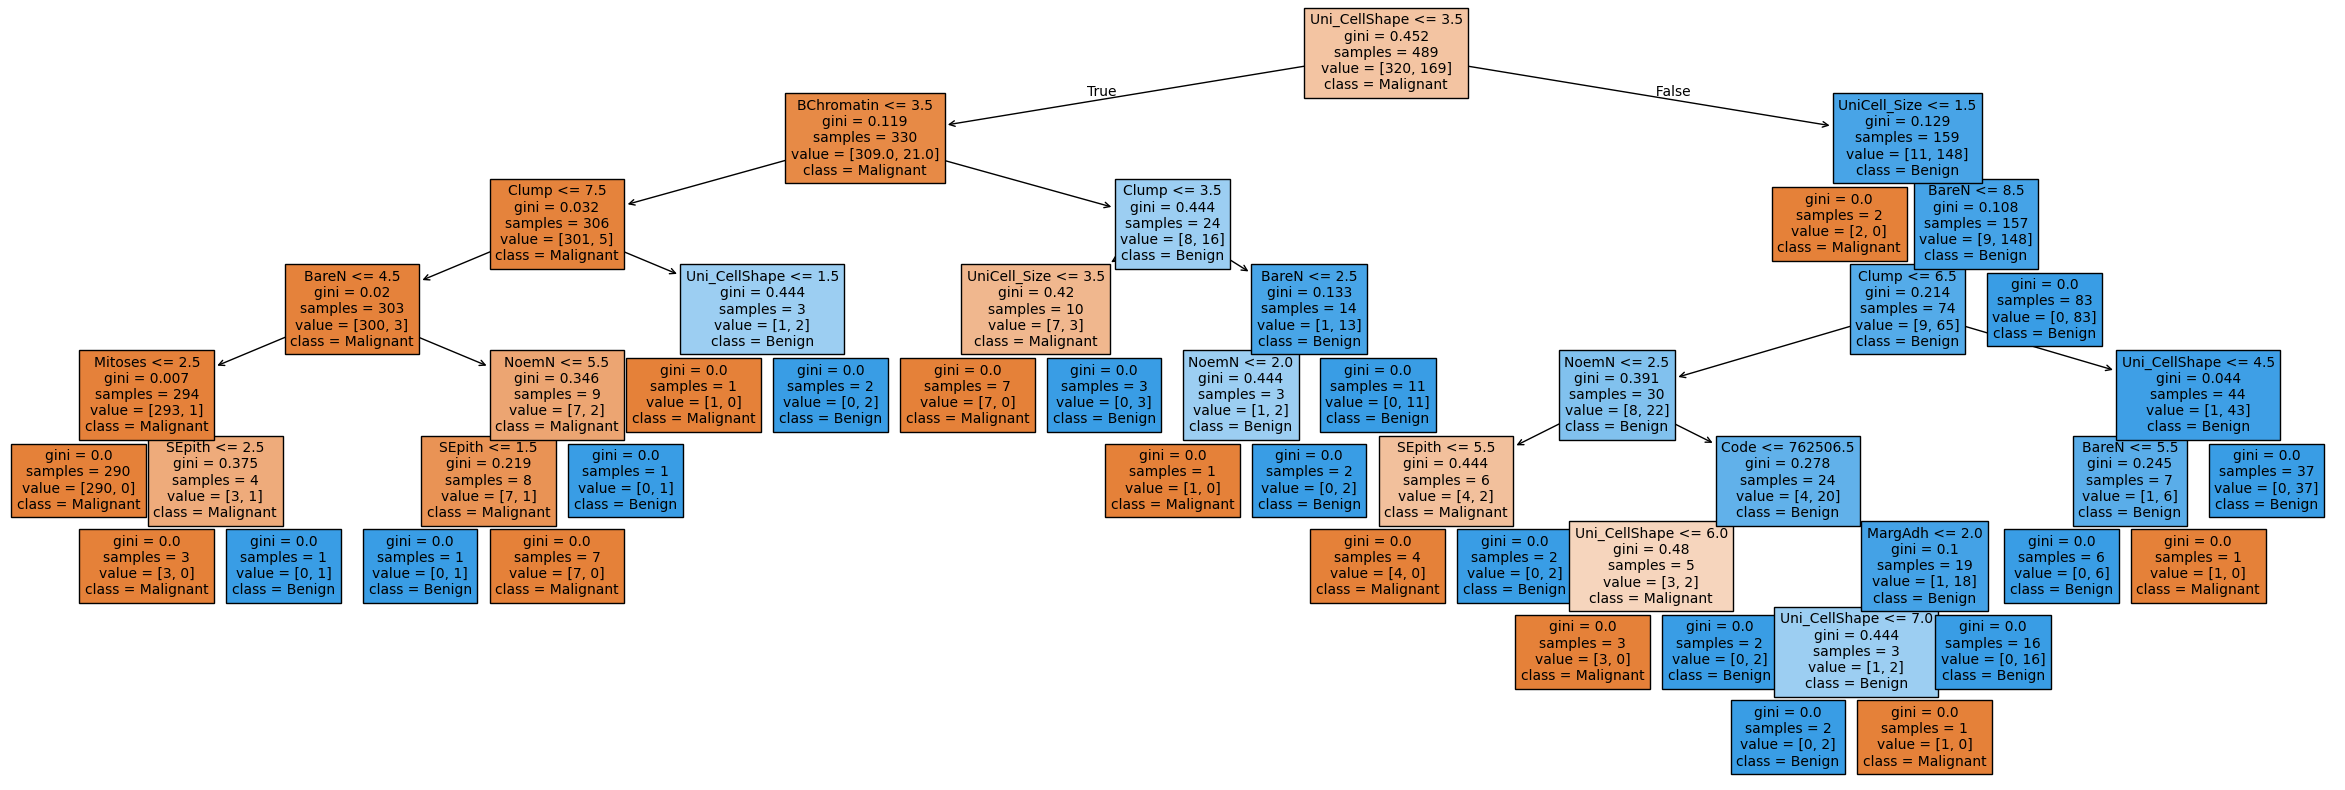

In [30]:
dtc=DecisionTreeClassifier(random_state=26)
dtc.fit(X_train,y_train)
plt.figure(figsize=(30,10))
plot_tree(dtc,feature_names=list(X.columns),class_names=["Malignant","Benign"],filled=True,fontsize=10)
plt.show()

In [31]:
y_pred=dtc.predict(X_test)
print("Acc=",accuracy_score(y_test,y_pred))
y_pred_prob=dtc.predict_proba(X_test)
print("log loss=",log_loss(y_test,y_pred_prob))

Acc= 0.9428571428571428
log loss= 2.0596373365209804


## depths

In [32]:
depths=[1,2,3,4,5]
scores=[]
for d in depths:
    dtc=DecisionTreeClassifier(random_state=26,max_depth=d)
    dtc.fit(X_train,y_train)
    y_pred_prob=dtc.predict_proba(X_test)
    scores.append([d,log_loss(y_test,y_pred_prob)])
df_scores=pd.DataFrame(scores,columns=["depths","score"])
df_scores.sort_values("score")

,depths,score
1,2,0.213198
2,3,0.342122
0,1,0.344786
3,4,0.454837
4,5,0.748255


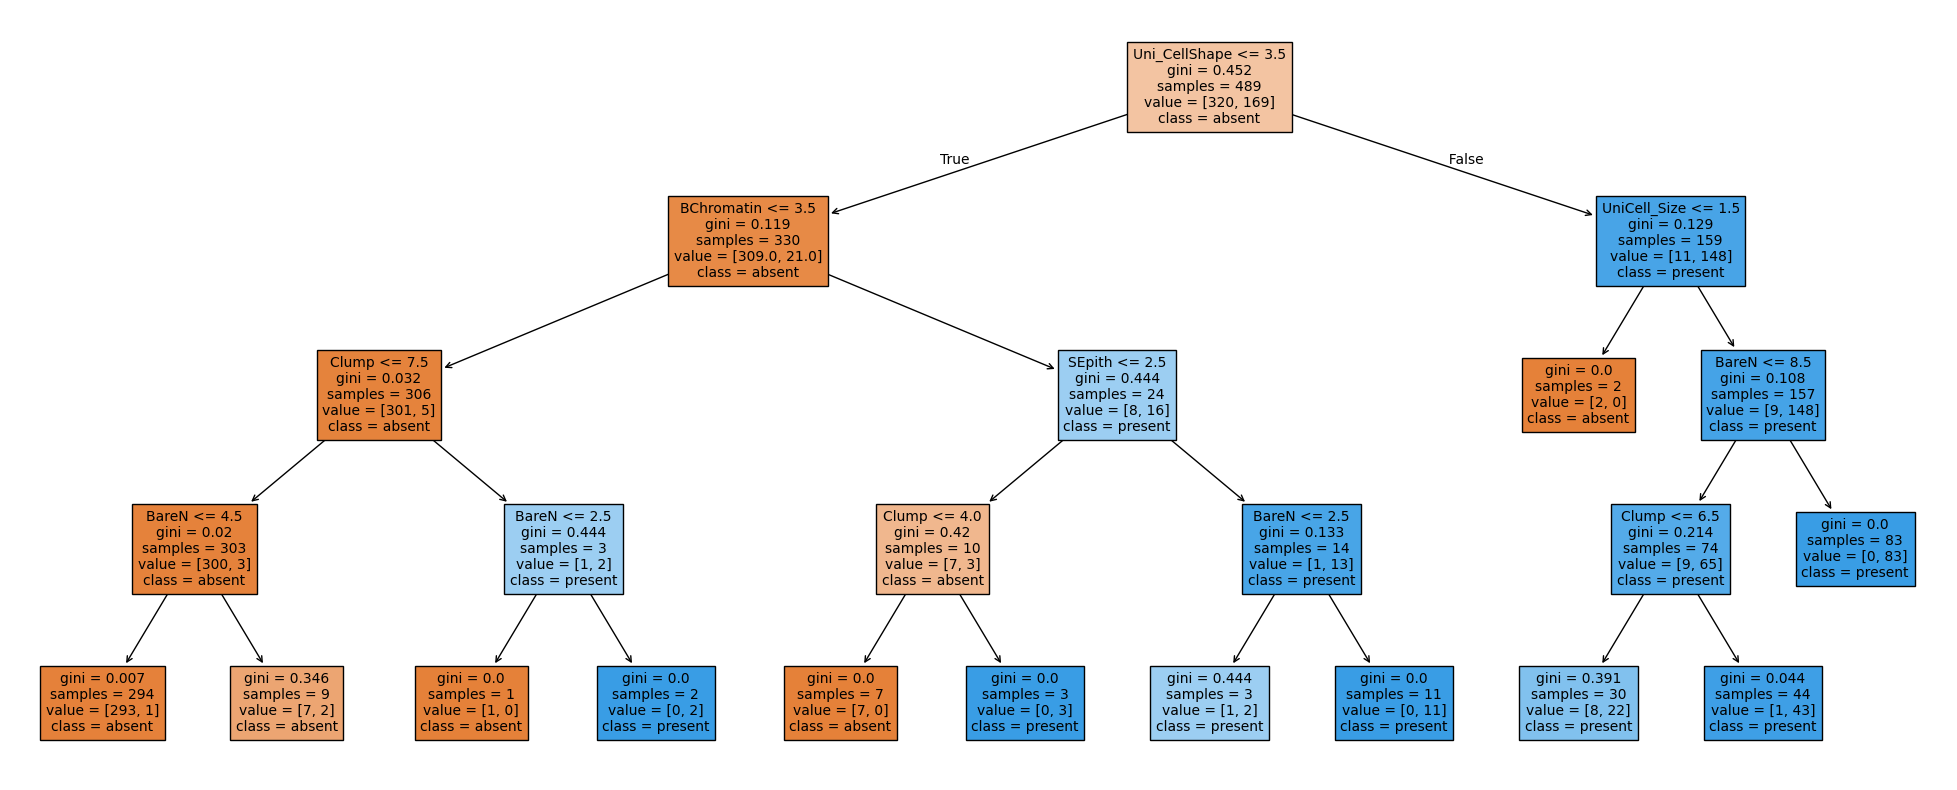

In [33]:
dtc=DecisionTreeClassifier(random_state=26,max_depth=4)

dtc.fit(X_train,y_train)
plt.figure(figsize=(25,10))
plot_tree(dtc,feature_names=list(X.columns),class_names=["Benign","Malignant"],filled=True,fontsize=10)
plt.show()

## splits

In [34]:
splits=[2,5,10,20,30]
scores=[]
for s in splits:
    dtc=DecisionTreeClassifier(random_state=26,min_samples_split=s)
    dtc.fit(X_train,y_train)
    y_pred_prob=dtc.predict_proba(X_test)
    scores.append([s,log_loss(y_test,y_pred_prob)])
df_scores=pd.DataFrame(scores,columns=["split","score"])
df_scores.sort_values("score")

,split,score
3,20,0.612786
4,30,0.618535
2,10,1.070263
1,5,1.225682
0,2,2.059637


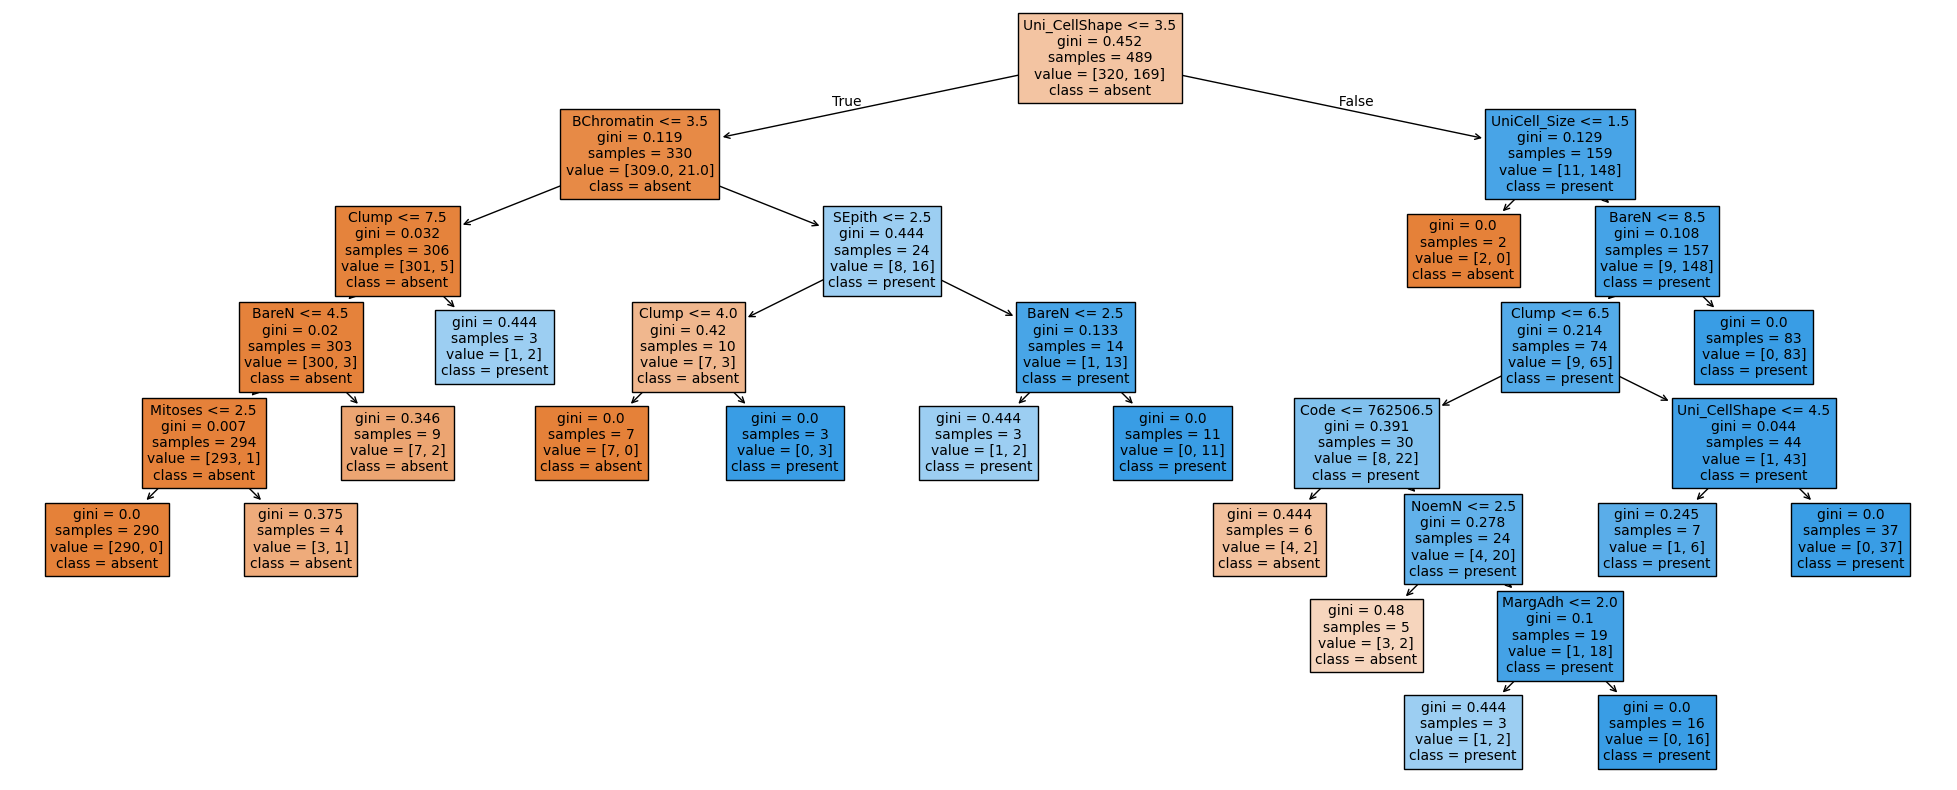

In [35]:
dtc=DecisionTreeClassifier(random_state=26,min_samples_split=10)

dtc.fit(X_train,y_train)
plt.figure(figsize=(25,10))
plot_tree(dtc,feature_names=list(X.columns),class_names=["Benign","Malignant"],filled=True,fontsize=10)
plt.show()

## leaves


In [36]:
leaves=[1,5,8,10,20]
# leaves=[10,20,1]

scores=[]
for l in leaves:
    dtc=DecisionTreeClassifier(random_state=26,min_samples_leaf=l)
    dtc.fit(X_train,y_train)
    y_pred_prob=dtc.predict_proba(X_test)
    scores.append([s,log_loss(y_test,y_pred_prob)])
df_scores=pd.DataFrame(scores,columns=["leaves","score"])
df_scores.sort_values("score")

,leaves,score
4,30,0.332581
2,30,0.453748
3,30,0.458915
1,30,0.910700
0,30,2.059637


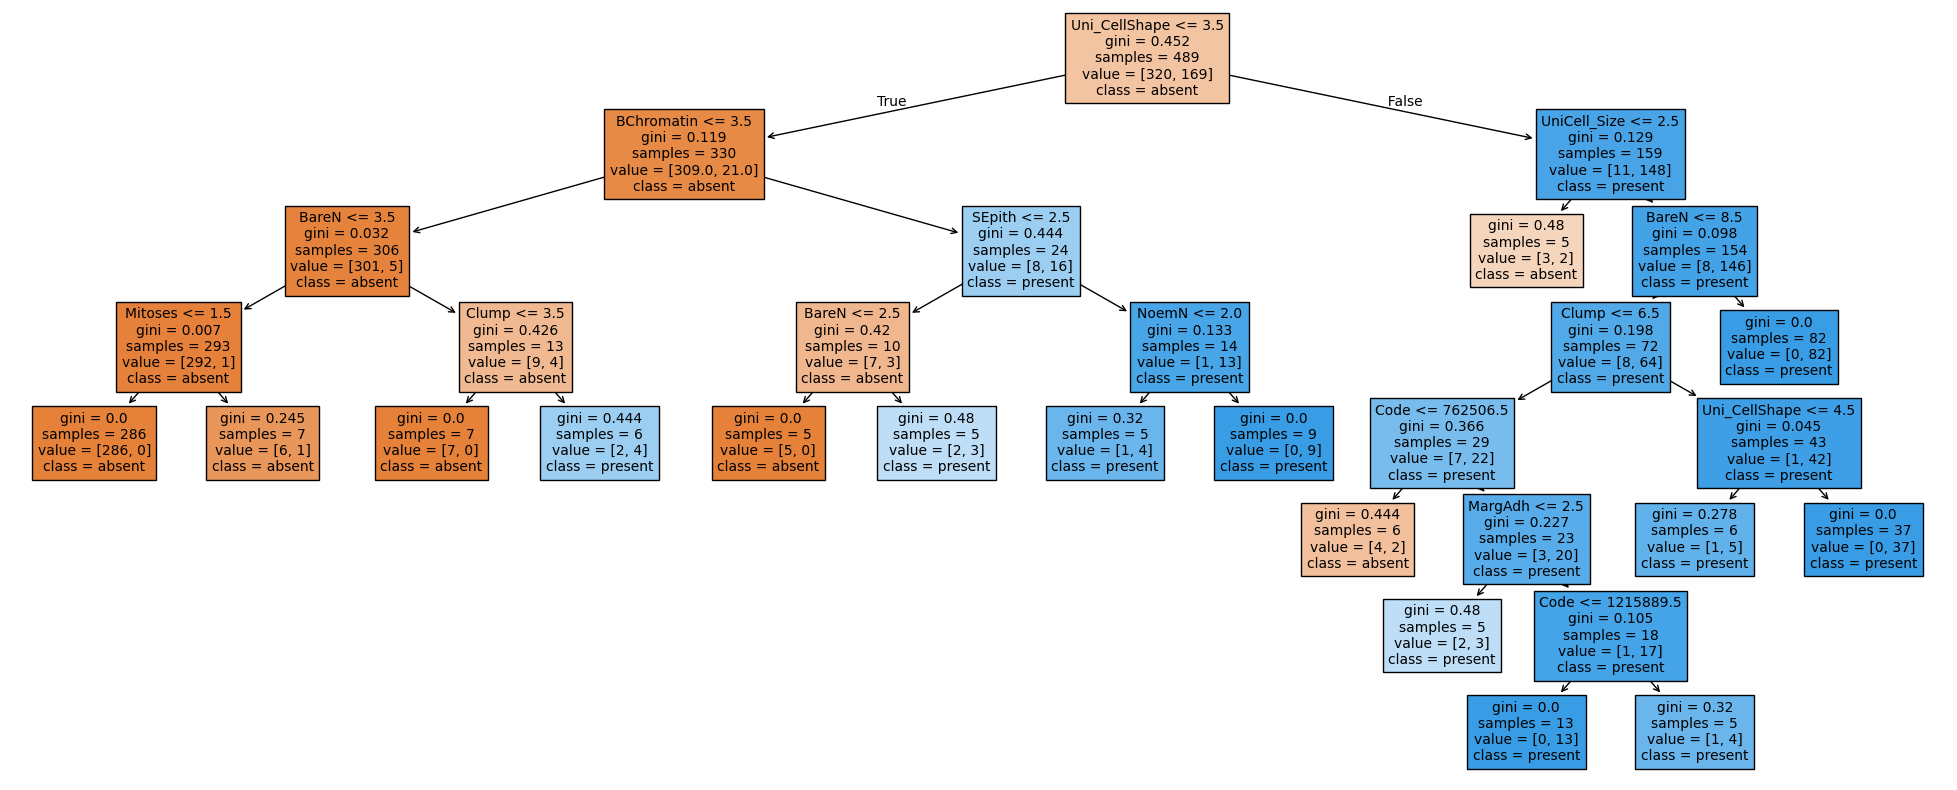

In [37]:
dtc=DecisionTreeClassifier(random_state=26,min_samples_leaf=5)

dtc.fit(X_train,y_train)
plt.figure(figsize=(25,10))
plot_tree(dtc,feature_names=list(X.columns),class_names=["Benign","Malignant"],filled=True,fontsize=10)
plt.show()

In [45]:
depths=np.arange(1,2,3,None)
splits=np.arange(2,4,8,10,20,30,50,100)
leaves=np.arange(1,4,8,10,20,30,50,100)
scores=[]
for d in tqdm(depths):
    for s in splits:
        for l in leaves:
            dtc=DecisionTreeClassifier(random_state=26,min_samples_leaf=l,min_samples_split=s,max_depth=d)
            dtc.fit(X_train,y_train)
            y_pred_prob=dtc.predict_proba(X_test)
            scores.append([d,s,l,log_loss(y_test,y_pred_prob)])
df_scores=pd.DataFrame(scores,columns=["depths","split","leaves","score"])
df_scores.sort_values("score")

TypeError: arange() takes from 0 to 4 positional arguments but 8 were given

## best fit

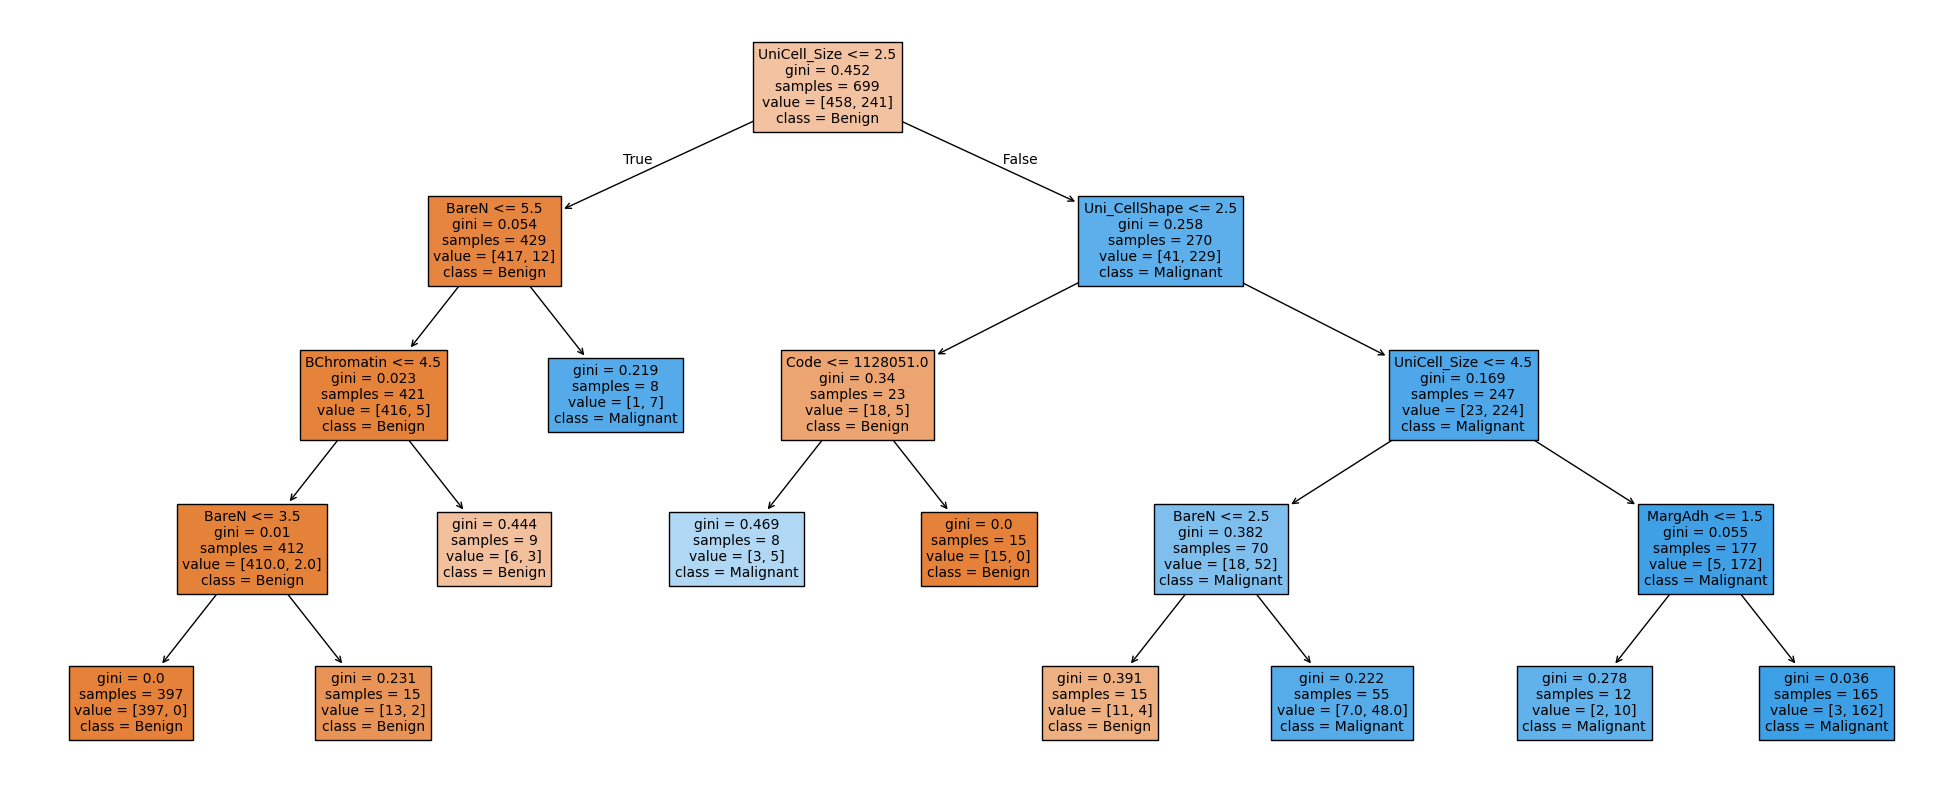

In [46]:
bm=DecisionTreeClassifier(random_state=26,min_samples_leaf=8,max_depth=4, min_samples_split=20)
bm.fit(X,y)
plt.figure(figsize=(25,10))
plot_tree(bm,feature_names=list(X.columns),class_names=["Benign","Malignant"],filled=True,fontsize=10)
plt.show()

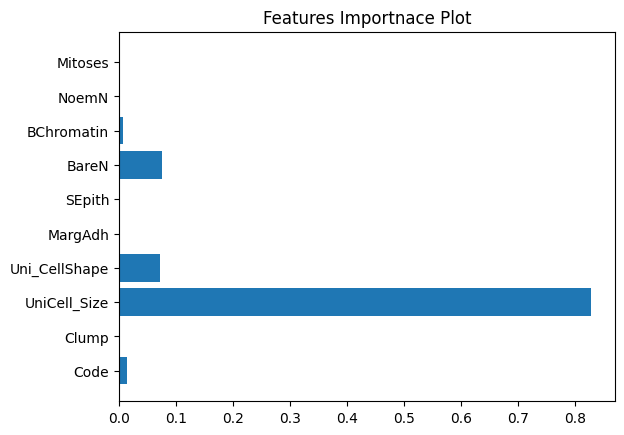

In [41]:
df_imp=pd.DataFrame({"feature":X.columns,"importance": bm.feature_importances_})
plt.barh(df_imp["feature"],df_imp["importance"])
plt.title("Features Importnace Plot")
plt.show()